## Aim :To build a deep learning model using an autoencoder on the MNIST dataset for removing noise from images and reconstructing clean images.

# 1 Imports + Load MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

(x_train, _), (x_test, _) = mnist.load_data()

2026-06-28 03:51:23.371627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782618683.617624      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782618683.692911      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782618684.279798      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782618684.279853      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782618684.279856      58 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 2 Normalize + Reshape

In [2]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(x_train.shape)

(60000, 28, 28, 1)


# 3 Add Noise

In [3]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 4 Build Autoencoder

In [4]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

2026-06-28 03:55:31.720425: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 5 Compile

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# 6 Train

In [7]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - loss: 0.1626 - val_loss: 0.0993
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 0.0964 - val_loss: 0.0923
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0914 - val_loss: 0.0888
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - loss: 0.0889 - val_loss: 0.0870
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - loss: 0.0872 - val_loss: 0.0861
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0860 - val_loss: 0.0850
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0851 - val_loss: 0.0838
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 0.0843 - val_loss: 0.0832
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0837 - val_loss: 0.0827
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0832 - val_loss: 0.0822


# 7 Predict

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)
print(decoded_imgs.min(), decoded_imgs.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
1.5445554e-12 0.99910766


# 8 Visualization

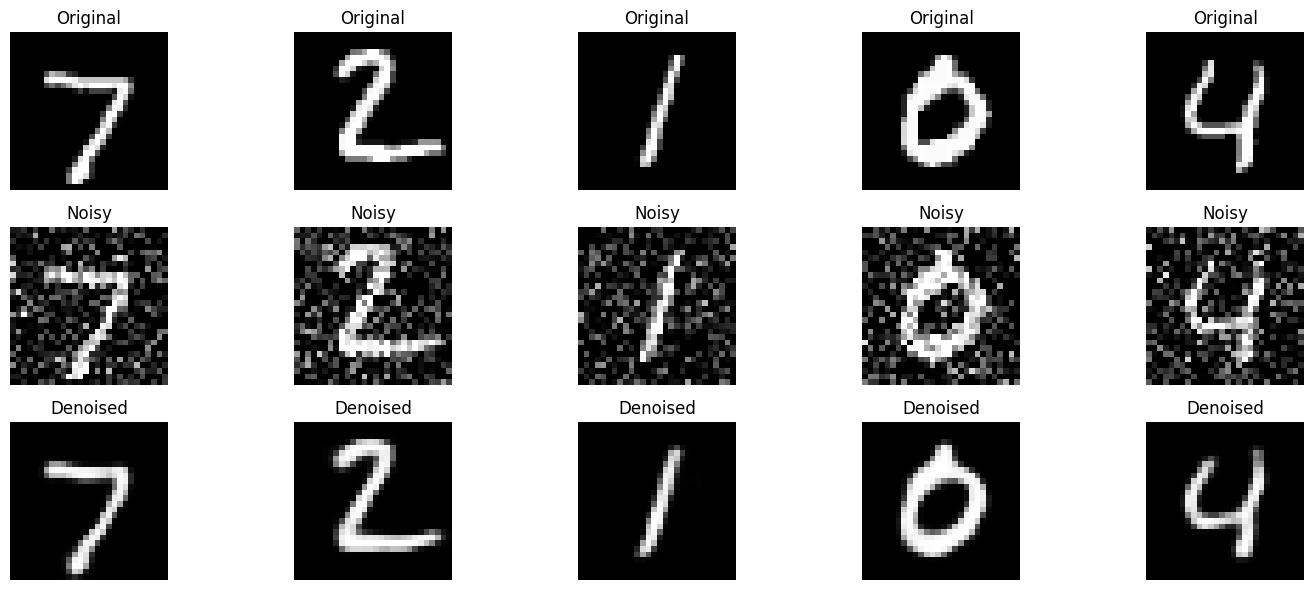

In [9]:
n = 5
plt.figure(figsize=(15, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

# 9 Plot Training Loss

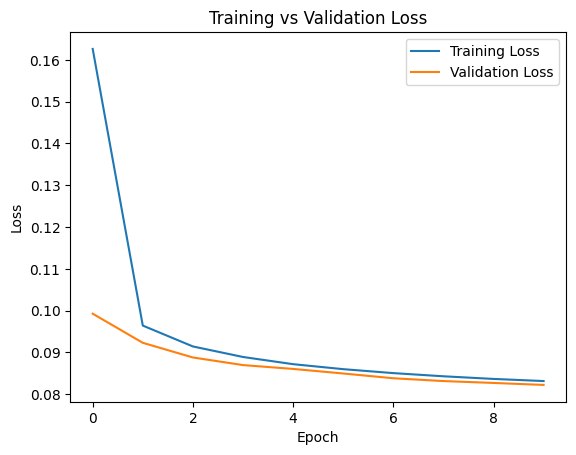

In [10]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

# 🖼️ Image Denoising Using Autoencoder on MNIST

## 📌 Project Overview

This notebook demonstrates how to build a **Convolutional Autoencoder** using TensorFlow/Keras to remove Gaussian noise from handwritten digit images in the MNIST dataset. The model is trained with noisy images as input and clean images as target output, enabling it to reconstruct denoised images effectively.

---

## 🎯 Objective

Build and train a deep learning autoencoder capable of reconstructing clean handwritten digit images from noisy inputs using the MNIST dataset.

---

## 📚 Dataset

* **Dataset:** MNIST
* **Training Images:** 60,000
* **Testing Images:** 10,000
* **Image Size:** 28 × 28 pixels
* **Channels:** Grayscale (1)

---

## 🛠️ Libraries Used

* TensorFlow / Keras
* NumPy
* Matplotlib

---

## 🔄 Workflow

1. Import required libraries.
2. Load the MNIST dataset.
3. Normalize and reshape the images.
4. Add Gaussian noise to the images.
5. Build a Convolutional Autoencoder.
6. Compile and train the model.
7. Predict denoised images.
8. Visualize original, noisy, and reconstructed images.
9. Plot training and validation loss.

---

## 🧠 Model Architecture

**Encoder**

* Conv2D (32 filters)
* MaxPooling2D
* Conv2D (16 filters)
* MaxPooling2D

**Decoder**

* Conv2D (16 filters)
* UpSampling2D
* Conv2D (32 filters)
* UpSampling2D
* Conv2D (1 filter, Sigmoid activation)

---

## ⚙️ Training Configuration

| Parameter     | Value               |
| ------------- | ------------------- |
| Optimizer     | Adam                |
| Loss Function | Binary Crossentropy |
| Epochs        | 10                  |
| Batch Size    | 128                 |
| Noise Type    | Gaussian Noise      |
| Noise Factor  | 0.3                 |

---

## 📊 Results

* Successfully reconstructed clean images from noisy inputs.
* Training loss decreased from approximately **0.1504** to **0.0819**.
* Validation loss decreased from approximately **0.0969** to **0.0810**.
* The reconstructed images preserved the important handwritten digit features while reducing noise.

---

## 📈 Output

The notebook displays:

* Original Images
* Noisy Images
* Denoised Images
* Training Loss Curve
* Validation Loss Curve

---

## 🎯 Key Learning Outcomes

* Image preprocessing with TensorFlow
* Gaussian noise generation
* Convolutional Autoencoders
* Image denoising techniques
* Model training and evaluation
* Deep learning for computer vision

---

## 🚀 Future Improvements

* Train on color image datasets (e.g., CIFAR-10)
* Implement U-Net for improved reconstruction
* Experiment with different noise levels
* Evaluate image quality using PSNR and SSIM metrics
* Apply the model to real-world image restoration tasks

---

## ✅ Conclusion

This project demonstrates that a Convolutional Autoencoder can effectively remove Gaussian noise from MNIST handwritten digit images. The trained model successfully reconstructs clean images while preserving essential digit features, making autoencoders a powerful approach for image denoising and restoration.

---